# This notebook we will run stochastic gradient descent 

Each step we sample from 
- etch depth $\sim\mathcal{N}(0,5nm)$
- alighnemnt $\sim\mathcal{N}(0,5nm)$
- Ovet/underetched $\sim\mathcal{N}(0,5nm)$

In [3]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web

import json

from main import (make_sim, get_coupling_efficiency, projection_builder, run_adam,
                    R, r0_extra, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, n_wl, wl_range,
                    to_substrate)


In [4]:
#set up random number generator
sigmas = [.005,.005]
rng = np.random.default_rng(seed=42)

N_teeth = 6

def objective(params,projection=None,path='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/tidy3d_output/temp.hdf5'):
    params_proj = projection(params)
    samples = rng.standard_normal(size=(len(sigmas))) * sigmas
    
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3] + samples[0]
    to_substrate = params_proj[N_teeth*2+4]

    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, N_teeth=N_teeth, dilation=samples[1], min_steps_per_wvl=20)
    sim_data = web.run(sim, task_name="GC4um_3D_opt", folder_name="dominic", verbose=False, path=path)
    return get_coupling_efficiency(sim_data)[n_wl//2] 

## 50nm minimum

In [5]:
from main import load_checkpoint
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/2d_opt/stochastic_opt_50nm_6teeth.json', 'r') as f:
    data = json.load(f)

params0 = data['params'][-1]
params0[N_teeth*2+2] += 3.8
#_,params0,opt_state,_ = load_checkpoint('data/3d_opt/tmp.pkl')

widths_bounds = (0.05, 0.6)
r0_bounds = (3,5)
etch_depth_bounds = (0.05, 0.2)
to_substrate_bounds = (.8,2)
project, inverse_project = projection_builder(widths_bounds=widths_bounds, 
                        r0_bounds=r0_bounds, 
                        etch_depth_bounds=etch_depth_bounds, 
                        to_substrate_bounds=to_substrate_bounds,
                        N_teeth=N_teeth)

history, opt_state = run_adam(np.array(params0), project, inverse_project, objective, num_steps=5, learning_rate=0.005, verbose=True)

14:10:34 EDT WARNING: Starting in version 2.11, the behavior of GaussianBeam    
             with direction '-' and non-zero 'waist_distance' has changed. The  
             waist position is now defined consistently for both forward- and   
             backward-propagating beams: a positive 'waist_distance' always     
             places the beam waist behind the source/monitor plane (toward the  
             negative normal axis). This ensures reciprocity between Gaussian   
             sources and overlap monitors used for port-based S-matrix          
             calculations. If your simulation relied on the previous behavior   
             (where the waist position flipped with direction), you may need to 
             adjust your waist distance values.                                 

KeyboardInterrupt: 

In [11]:
def objective_no_random(params,projection=None):
    params_proj = projection(params)
    
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, min_steps_per_wvl=30)
    fig, ax = plt.subplots(2,1)
    sim.plot_eps(y=0,ax=ax[0])
    sim.plot_eps(z=.2,ax=ax[1])
    plt.tight_layout()
    plt.show()
    sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

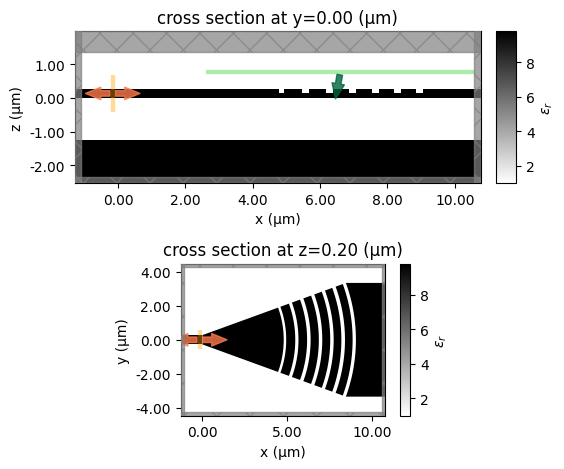

np.float64(0.64552830969966)

In [12]:
objective_no_random(inverse_project(np.array(history["params"][-1])),projection=project)

In [13]:
# Save the optimization history to disk in a human-readable JSON file.
with open("data/3d_opt/stochastic_3D_opt_50nm.json", "w") as f:
    json.dump(history, f, indent=2)

In [22]:
for i,g in enumerate(history['grad']):
    if i!=0:
        print((np.arccos(np.dot(g, history['grad'][i-1])/(np.linalg.norm(g)*np.linalg.norm(history['grad'][i-1]))))*180/np.pi)

76.4289617612287
93.12120717794919
14.427654112445172
11.224045663148525
